In [40]:
## Imports from 1_clean_merge_data.ipynb
import pandas as pd
import numpy as np
import re
import requests
import yaml
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
import time

## Set font parameters early
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams['font.size'] = 13

headers = {
    'User-Agent': 'EskildsenLogan research project (logan.j.eskildsen.28@dartmouth.edu)'
}

## Repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [43]:
## Load relevant search trend data for visualization
regional_final_df = pd.read_csv('../data/regional_final_data.csv')

In [45]:
regional_final_df['cultural_interest'] = regional_final_df['cultural_interest_1'] + regional_final_df['cultural_interest_2']
regional_final_df['match_interest'] = regional_final_df['match_interest_1'] + regional_final_df['match_interest_2']

regional_final_df


,Unnamed: 0,country,geo_code,date,cultural_interest_1,cultural_interest_2,match_interest_1,match_interest_2,city,cultural_interest,match_interest
0,0,Australia,US-CA-803,2026-05-17,1,0,0,0,Los Angeles CA,1,0
1,1,Australia,US-CA-803,2026-05-24,13,1,5,0,Los Angeles CA,14,5
2,2,Australia,US-CA-803,2026-05-31,12,0,19,13,Los Angeles CA,12,32
3,3,Australia,US-CA-803,2026-06-07,14,0,19,2,Los Angeles CA,14,21
4,4,Australia,US-CA-803,2026-06-14,16,1,129,17,Los Angeles CA,17,146
...,...,...,...,...,...,...,...,...,...,...,...
835,835,Turkey,US-WA-819,2026-07-26,0,0,0,0,Seattle WA,0,0
836,836,Turkey,US-WA-819,2026-08-02,0,0,0,0,Seattle WA,0,0
837,837,Turkey,US-WA-819,2026-08-09,0,0,0,0,Seattle WA,0,0
838,838,Turkey,US-WA-819,2026-08-16,0,0,0,0,Seattle WA,0,0


Text(0.5, 1.0, 'Los Angeles CA')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'log(1 + Proportion)')

Text(0.5, 1.0, 'San Francisco CA')

Text(0.5, 0, 'Date')

...

Text(0, 0.5, 'log(1 + Proportion)')

Text(0.5, 1.0, 'Chicago IL')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'log(1 + Proportion)')

Text(0.5, 1.04, 'Proportional Search Engagement by Host City, Country')

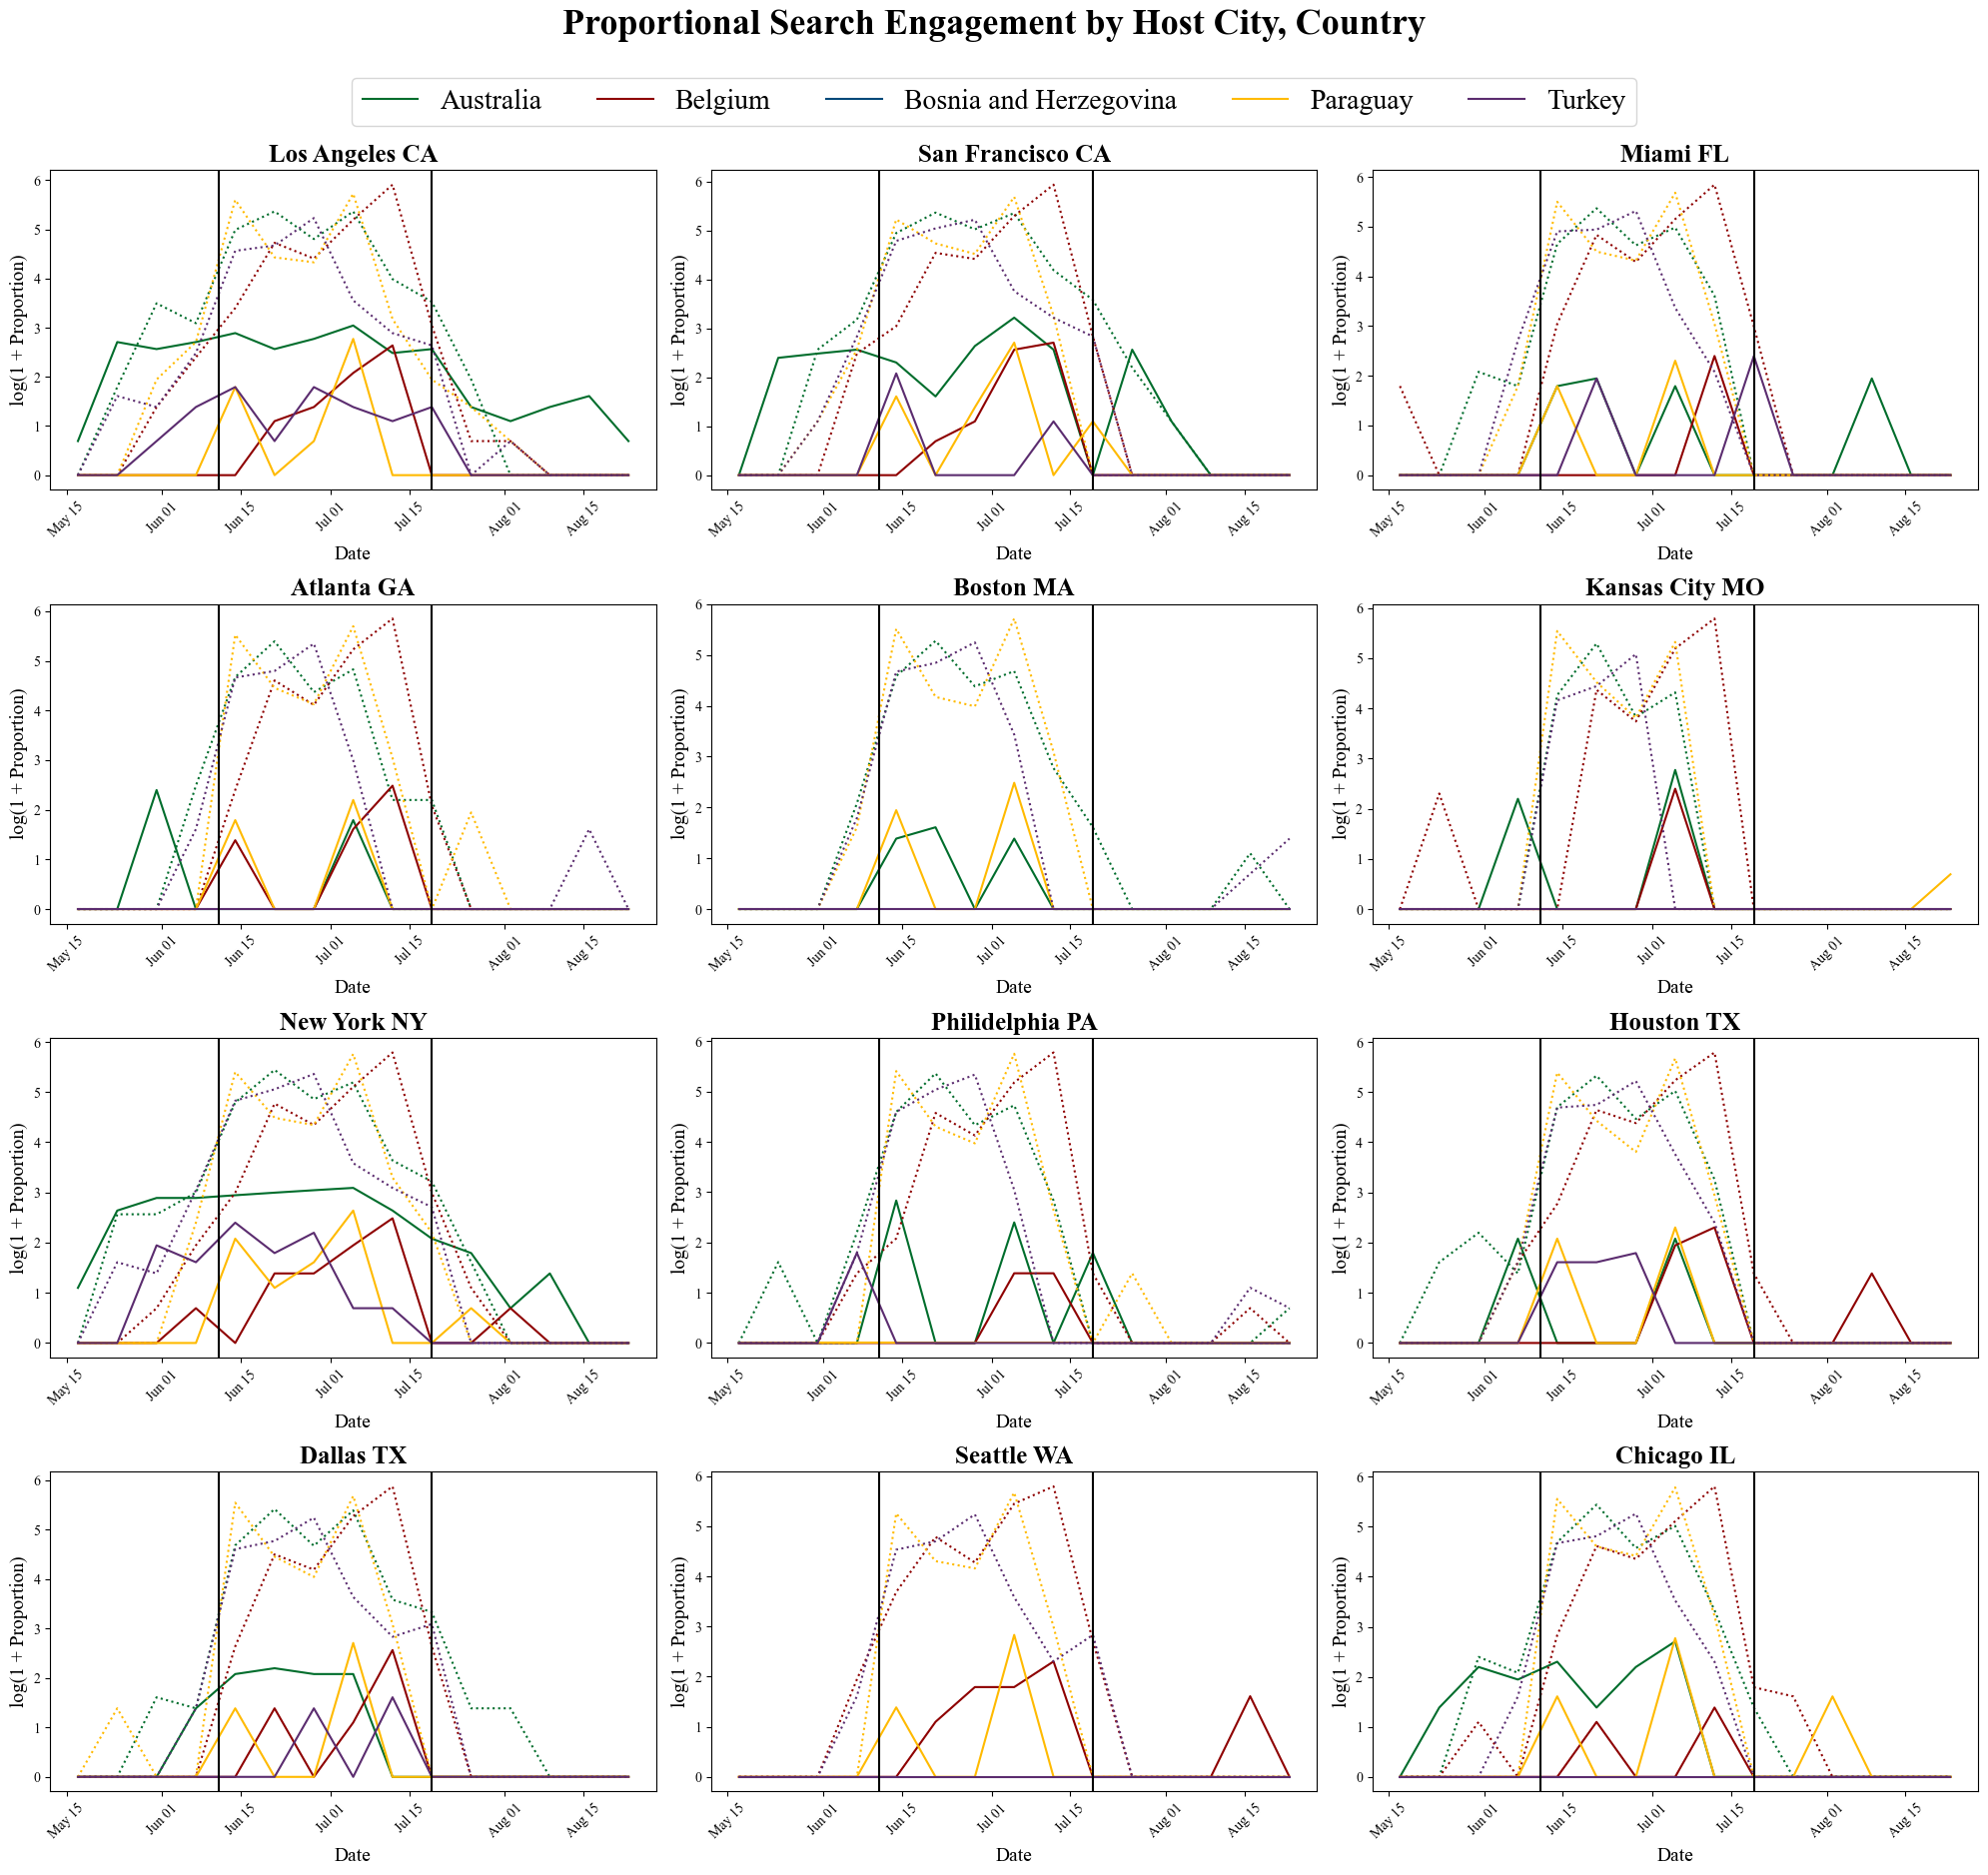

In [62]:
regional_final_df['date'] = pd.to_datetime(regional_final_df['date'])

## Use list comprehension and remove Chicago to plot it last
cities = [c for c in regional_final_df['city'].unique() if c != 'Chicago IL'] + ['Chicago IL']
countries = regional_final_df['country'].str.replace('_', ' ').unique()

## Associated colors in the list of countries, same thought process as in notebook 2_visualize_wikipedia_outputs
colors = ['#006D2C', '#8E0000', '#004879', '#FFBA00', '#5B2C6F']

## Define window for the actual WOrld Cup
cup_start = pd.Timestamp('2026-06-11')
cup_end = pd.Timestamp('2026-07-19')
 
fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.flatten()

## Combine arrays, filter to rows for selected city, plot log of cultural and match interest over time, 12 times.
for ax, city in zip(axes, cities):
    city_df = regional_final_df[regional_final_df['city'] == city]
    for country, color in zip(countries, colors):
        dates = city_df[city_df['country'] == country].sort_values('date')
        ax.plot(dates['date'], np.log1p(dates['cultural_interest']), linestyle='-', color=color, label=country)
        ax.plot(dates['date'], np.log1p(dates['match_interest']), linestyle=':', color=color)
    ax.axvline(cup_start, linestyle='-', color='black')
    ax.axvline(cup_end, linestyle='-', color='black')
    ax.set_title(city, fontsize=18, fontweight='bold')
    ax.set_xlabel('Date', fontsize=14)
    ax.set_ylabel('log(1 + Proportion)', fontsize=14)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=45)

## Labels for each country color
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=5, fontsize=20)

plt.suptitle('Proportional Search Engagement by Host City, Country', fontsize=26, y=1.04, fontweight='bold')
plt.tight_layout()
## Large figure, save with high resultion
plt.savefig('../outputs/figure_6.png', dpi=600, bbox_inches='tight')
plt.show()